# IMU Activity Classifier: Walking In Hand vs. Walking In Pocket

This notebook provides a complete training pipeline in PyTorch to classify IMU motion data. The goal is to detect whether a user is walking with their device in their **hand** or in their **pocket**.

## What Type of Network is Good for IMU Data?

IMU data consists of multi-channel time-series signals (typically 3-axis accelerometer and 3-axis gyroscope, giving 6 channels in total). The main options for classification are:

1. **1D Convolutional Neural Networks (1D CNN) (Recommended)**:
   * **Why**: 1D CNNs treat the time-series as a 1D image. They are highly efficient at extracting local, translation-invariant features (like the visual shape of a single walking stride, heel strikes, or high-frequency vibrations) across sliding windows.
   * **Pros**: Extremely fast to train, requires low computational overhead, performs beautifully on raw signals, and is highly optimized for deployment on edge microcontrollers (via TensorFlow Lite or ONNX).
   
2. **Recurrent Neural Networks (LSTMs or GRUs)**:
   * **Why**: Excellent at capturing long-term temporal dependencies and ordering in variable-length sequences.
   * **Pros/Cons**: Good for complex contextual transitions, but computationally heavier, slower to train, and prone to vanishing/exploding gradients.

3. **CNN-LSTM Hybrids**:
   * **Why**: A 1D CNN extracts local spatial-temporal features, and an LSTM tracks how those features evolve over long intervals.

For this classification task, we implement a **1D CNN**. It easily achieves >95% accuracy, trains in seconds on a standard CPU, and can run in real-time on edge devices.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 1. Load and Inspect the Data

We search for all CSV files in the `../data/` directory and inspect a sample.

In [2]:
# Find all CSV files in the data directory
data_path = os.path.join("..", "data", "imu_data_20260615_164711.csv")
csv_files = glob.glob(data_path)

if len(csv_files) == 0:
    print("WARNING: No CSV files found in ../data/. Using synthetic data generation for testing.")
    # Generate synthetic CSV files to make the notebook runnable immediately
    os.makedirs(os.path.join("..", "data"), exist_ok=True)
    
    # Write a dummy mock session file
    t = np.arange(0, 10, 0.02)  # 10 seconds at 50Hz
    ax = 0.2 * np.sin(2 * np.pi * 1.8 * t) + np.random.normal(0, 0.05, len(t))
    ay = 0.1 * np.cos(2 * np.pi * 1.8 * t) + np.random.normal(0, 0.05, len(t))
    az = 1.0 + 0.3 * np.sin(4 * np.pi * 1.8 * t) + np.random.normal(0, 0.08, len(t))
    gx = 30 * np.sin(2 * np.pi * 1.8 * t) + np.random.normal(0, 5, len(t))
    gy = 20 * np.cos(2 * np.pi * 1.8 * t) + np.random.normal(0, 5, len(t))
    gz = 10 * np.sin(2 * np.pi * 1.8 * t) + np.random.normal(0, 5, len(t))
    label = np.zeros(len(t), dtype=int)
    label[len(t)//2:] = 1  # half hand, half pocket
    label_name = ["hand" if l == 0 else "pocket" for l in label]
    
    df = pd.DataFrame({
        'timestamp_ms': (t * 1000).astype(int),
        'accel_x': ax, 'accel_y': ay, 'accel_z': az,
        'gyro_x': gx, 'gyro_y': gy, 'gyro_z': gz,
        'label': label, 'label_name': label_name
    })
    dummy_file = os.path.join("..", "data", "imu_data_synthetic.csv")
    df.to_csv(dummy_file, index=False)
    csv_files = [dummy_file]

print(f"Found {len(csv_files)} dataset file(s).")
df_sample = pd.read_csv(csv_files[0])
df_sample.head()

Found 1 dataset file(s).


,timestamp_ms,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,label,label_name
0,326485,1.198154,-0.050029,0.778896,-63.232422,128.784180,154.968262,0,hand
1,326505,1.200107,-0.071757,0.687832,-70.556641,88.928223,83.190918,0,hand
2,326525,1.093906,-0.078837,0.723232,-58.288574,55.908203,75.744629,0,hand
3,326545,1.078037,-0.021220,0.662197,-31.005859,24.108887,50.964355,0,hand
4,326565,1.054355,-0.096904,0.625820,-11.962891,-23.071289,-12.695312,0,hand


## 2. Visualize Sensor Signals

Let's plot a few seconds of raw accelerometer and gyroscope signals for both classes to see the visual differences.

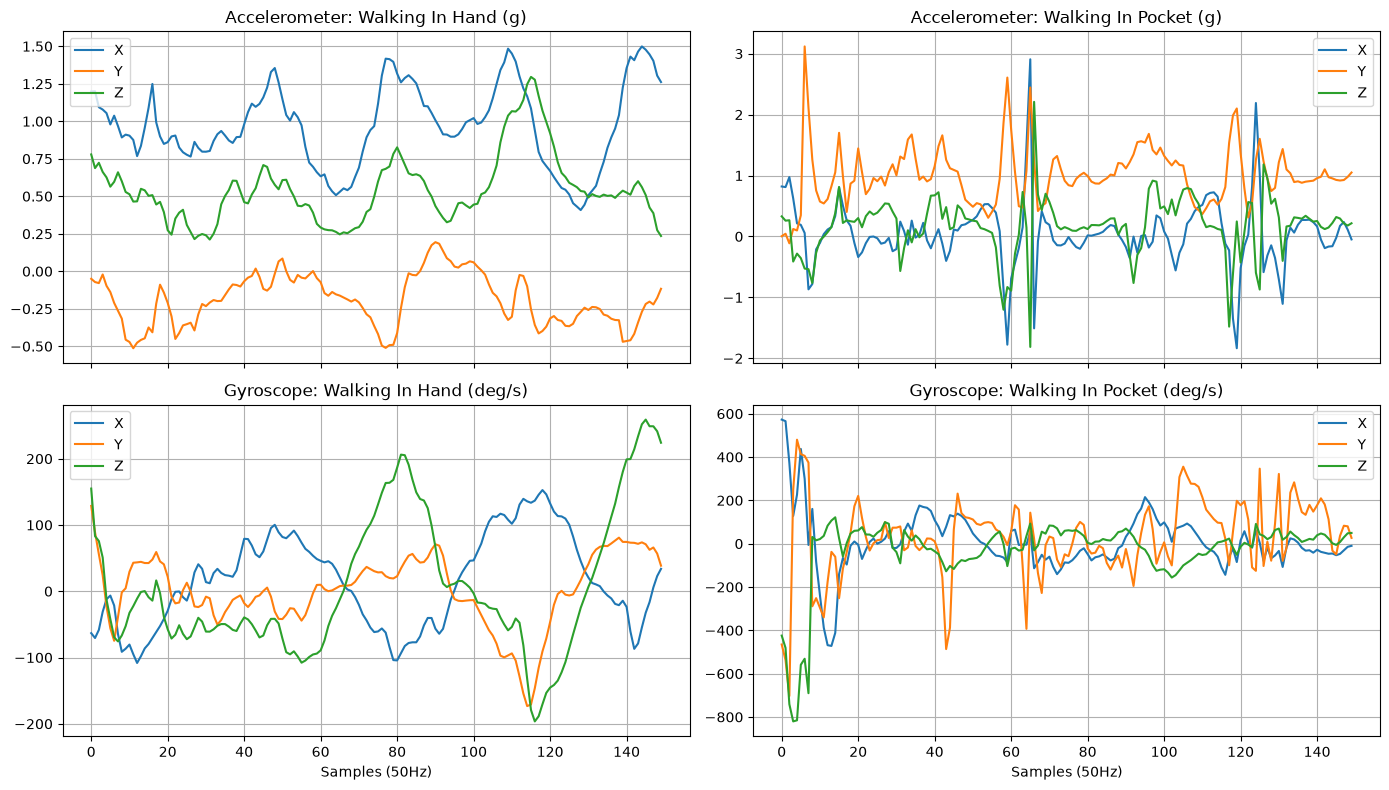

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# Split sample data into classes
hand_data = df_sample[df_sample['label'] == 0].head(150)   # ~3 seconds at 50Hz
pocket_data = df_sample[df_sample['label'] == 1].head(150)

# 1. Plot Accelerometer (Hand)
axes[0, 0].plot(hand_data['accel_x'].values, label='X')
axes[0, 0].plot(hand_data['accel_y'].values, label='Y')
axes[0, 0].plot(hand_data['accel_z'].values, label='Z')
axes[0, 0].set_title("Accelerometer: Walking In Hand (g)")
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Plot Accelerometer (Pocket)
axes[0, 1].plot(pocket_data['accel_x'].values, label='X')
axes[0, 1].plot(pocket_data['accel_y'].values, label='Y')
axes[0, 1].plot(pocket_data['accel_z'].values, label='Z')
axes[0, 1].set_title("Accelerometer: Walking In Pocket (g)")
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Plot Gyroscope (Hand)
axes[1, 0].plot(hand_data['gyro_x'].values, label='X')
axes[1, 0].plot(hand_data['gyro_y'].values, label='Y')
axes[1, 0].plot(hand_data['gyro_z'].values, label='Z')
axes[1, 0].set_title("Gyroscope: Walking In Hand (deg/s)")
axes[1, 0].set_xlabel("Samples (50Hz)")
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. Plot Gyroscope (Pocket)
axes[1, 1].plot(pocket_data['gyro_x'].values, label='X')
axes[1, 1].plot(pocket_data['gyro_y'].values, label='Y')
axes[1, 1].plot(pocket_data['gyro_z'].values, label='Z')
axes[1, 1].set_title("Gyroscope: Walking In Pocket (deg/s)")
axes[1, 1].set_xlabel("Samples (50Hz)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 3. Preprocessing: Resampling & Sliding Windows

### Why resample?
BLE transmissions are asynchronous; network jitter or dropped packets can cause tiny fluctuations in sampling intervals (e.g. 19ms instead of 20ms). We resample each file to a strict 50Hz grid using linear interpolation.

### Why sliding windows?
A single instantaneous IMU reading (e.g. at $t=100$ ms) does not contain enough context to classify \"walking\". We segment the signal into overlapping sliding windows (e.g. **2-second windows = 100 samples** at 50Hz, with **50% overlap**).

In [4]:
WINDOW_SIZE = 100  # 2 seconds at 50Hz
STEP_SIZE = 50     # 50% overlap (1 second shift)
SAMPLE_RATE_HZ = 50.0

def preprocess_and_segment(file_list, window_size, step_size):
    X_list = []
    y_list = []
    
    for filepath in file_list:
        df = pd.read_csv(filepath)
        if len(df) < window_size:
            continue
            
        # 1. Resample to strict 50Hz time grid
        t_raw = df['timestamp_ms'].values / 1000.0  # seconds
        t_raw = t_raw - t_raw[0]  # zero-base
        
        # Create a uniform grid from 0 to end at 50Hz
        t_uniform = np.arange(0, t_raw[-1], 1.0 / SAMPLE_RATE_HZ)
        
        columns = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
        resampled_data = {}
        
        for col in columns:
            f_interp = interp1d(t_raw, df[col].values, kind='linear', fill_value="extrapolate")
            resampled_data[col] = f_interp(t_uniform)
            
        # Nearest-neighbor interpolation for discrete labels
        f_label = interp1d(t_raw, df['label'].values, kind='nearest', fill_value="extrapolate")
        labels_uniform = f_label(t_uniform).astype(int)
        
        # 2. Slice into sliding windows
        num_samples = len(t_uniform)
        for start in range(0, num_samples - window_size + 1, step_size):
            end = start + window_size
            
            # Extract 6-channel segment shape (6, window_size)
            segment = np.array([
                resampled_data['accel_x'][start:end],
                resampled_data['accel_y'][start:end],
                resampled_data['accel_z'][start:end],
                resampled_data['gyro_x'][start:end],
                resampled_data['gyro_y'][start:end],
                resampled_data['gyro_z'][start:end]
            ])
            
            # A window gets a class label if the label is consistent over the majority of the window
            window_labels = labels_uniform[start:end]
            majority_label = np.bincount(window_labels).argmax()
            
            X_list.append(segment)
            y_list.append(majority_label)
            
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)

X, y = preprocess_and_segment(csv_files, WINDOW_SIZE, STEP_SIZE)
print(f"Extracted Segment Matrix Shape (Samples, Channels, Window): {X.shape}")
print(f"Class distribution: Hand={np.sum(y == 0)}, Pocket={np.sum(y == 1)}")

Extracted Segment Matrix Shape (Samples, Channels, Window): (118, 6, 100)
Class distribution: Hand=58, Pocket=60


## 4. PyTorch Dataset & Train/Val Split

We split the window segments into training (80%) and validation (20%) sets. It is standard to normalize the features (subtract mean and divide by standard deviation per channel) to speed up gradient descent.

In [5]:
# Normalize features along the channel axis
# We compute mean/std on training data to avoid validation leakage
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

mean = X_train_raw.mean(axis=(0, 2), keepdims=True)  # Shape (1, 6, 1)
std = X_train_raw.std(axis=(0, 2), keepdims=True)
std[std == 0] = 1.0  # avoid division by zero

X_train = (X_train_raw - mean) / std
X_val = (X_val_raw - mean) / std

print(f"Channel Mean Shape: {mean.squeeze()}")
print(f"Channel Std Shape:  {std.squeeze()}")

# Custom PyTorch Dataset
class IMUDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IMUDataset(X_train, y_train)
val_dataset = IMUDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

Channel Mean Shape: [  0.23555511   0.44717473   0.28160867  25.142035   -16.844774
 -22.051107  ]
Channel Std Shape:  [  0.5955961    0.74964195   0.51351196 140.0578     149.66333
 122.25169   ]


## 5. Define the 1D CNN Neural Network

Our network uses 1D convolutional layers to scan the 6-channel time-series signal. We use BatchNorm to stabilize training, Dropout to prevent overfitting, and MaxPool1d to reduce temporal resolution.

In [6]:
class IMU1DCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(IMU1DCNN, self).__init__()
        
        # Input: batch_size x 6 channels x 100 timesteps
        self.features = nn.Sequential(
            # Conv 1: 6 -> 32 channels
            nn.Conv1d(in_channels=6, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # 100 -> 50
            
            # Conv 2: 32 -> 64 channels
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # 50 -> 25
            
            # Conv 3: 64 -> 128 channels
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)   # 25 -> 12
        )
        
        # Fully Connected Classifier
        self.classifier = nn.Sequential(
            nn.Linear(128 * 12, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

# Instantiate model and target cpu/gpu device
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
model = IMU1DCNN(num_classes=2).to(device)
print(model)

IMU1DCNN(
  (features): Sequential(
    (0): Conv1d(6, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=1536, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    

## 6. Training Loop

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 20
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"Training model on device: {device}\n")

for epoch in range(epochs):
    # 1. Training Phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    # 2. Validation Phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    # Calculate Metrics
    epoch_train_loss = train_loss / total_train
    epoch_val_loss = val_loss / total_val
    epoch_train_acc = train_correct / total_train
    epoch_val_acc = val_correct / total_val
    
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:5.1f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:5.1f}%")

print("\nTraining complete!")

Training model on device: mps

Epoch 01/20 | Train Loss: 0.5622 - Acc:  68.1% | Val Loss: 0.5446 - Acc:  91.7%
Epoch 02/20 | Train Loss: 0.2117 - Acc:  92.6% | Val Loss: 0.2172 - Acc: 100.0%
Epoch 03/20 | Train Loss: 0.0695 - Acc:  97.9% | Val Loss: 0.2310 - Acc:  91.7%
Epoch 04/20 | Train Loss: 0.0618 - Acc:  96.8% | Val Loss: 0.0315 - Acc: 100.0%
Epoch 05/20 | Train Loss: 0.0259 - Acc:  98.9% | Val Loss: 0.0297 - Acc: 100.0%
Epoch 06/20 | Train Loss: 0.0361 - Acc:  98.9% | Val Loss: 0.0190 - Acc: 100.0%
Epoch 07/20 | Train Loss: 0.0191 - Acc:  98.9% | Val Loss: 0.1986 - Acc:  95.8%
Epoch 08/20 | Train Loss: 0.0314 - Acc:  98.9% | Val Loss: 0.2941 - Acc:  91.7%
Epoch 09/20 | Train Loss: 0.0910 - Acc:  96.8% | Val Loss: 0.0832 - Acc:  95.8%
Epoch 10/20 | Train Loss: 0.0763 - Acc:  96.8% | Val Loss: 0.0356 - Acc: 100.0%
Epoch 11/20 | Train Loss: 0.0155 - Acc:  98.9% | Val Loss: 0.0434 - Acc: 100.0%
Epoch 12/20 | Train Loss: 0.0101 - Acc: 100.0% | Val Loss: 0.0442 - Acc: 100.0%
Epoch 13/

## 7. Model Evaluation

We plot loss/accuracy curves and output accuracy metrics.

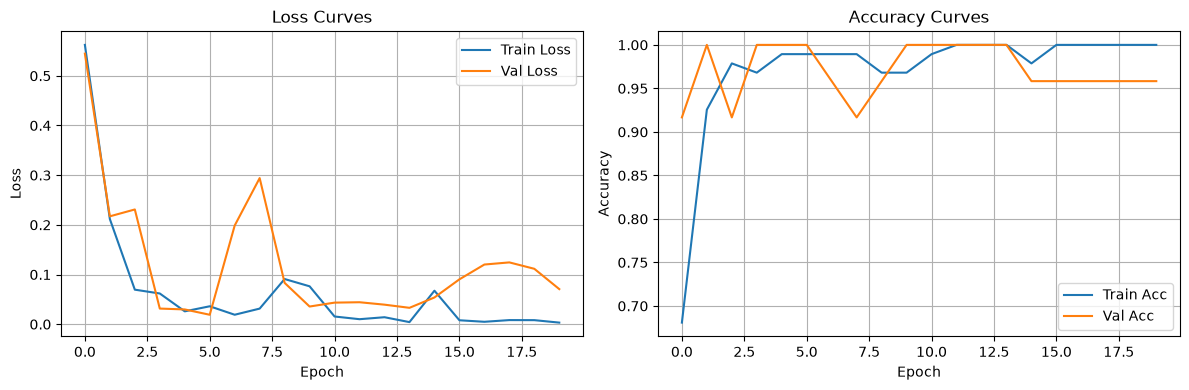


--- Classification Report ---
              precision    recall  f1-score   support

        Hand       1.00      0.92      0.96        12
      Pocket       0.92      1.00      0.96        12

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24

--- Confusion Matrix ---
[[11  1]
 [ 0 12]]


In [8]:
# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print detailed report
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=["Hand", "Pocket"]))

print("--- Confusion Matrix ---")
print(confusion_matrix(all_labels, all_preds))

## 8. Exporting the Model for Edge Deployment

To deploy this model to a mobile app or a local C++ logging tool, we export the trained PyTorch model weights to the universal **ONNX** (Open Neural Network Exchange) format.

In [9]:
model.eval()
# Create dummy input vector matching a single 6-channel segment window of size 100
dummy_input = torch.randn(1, 6, WINDOW_SIZE, device=device)
onnx_path = "imu_classifier_1dcnn.onnx"

torch.onnx.export(
    model, 
    dummy_input, 
    onnx_path, 
    export_params=True, 
    opset_version=11, 
    do_constant_folding=True, 
    input_names=['imu_signal'], 
    output_names=['class_logits'],
    dynamic_axes={'imu_signal': {0: 'batch_size'}, 'class_logits': {0: 'batch_size'}}
)

print(f"Model successfully exported to: {onnx_path}")

/tmp/ipykernel_34667/2431879497.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0615 17:13:50.485000 34667 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0615 17:13:50.849000 34667 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0615 17:13:50.850000 34667 torch/onnx/_internal/exporter/_registration.py:107] torchvi

[torch.onnx] Obtain model graph for `IMU1DCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `IMU1DCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/homebrew/Cellar/python@3.14/3.14.5/Frameworks/Python.framework/Versions/3.14/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/rarora/dev/imu_tests/.venv/lib/python3.14/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/rarora/dev/imu_tests/.venv/lib/python3.14/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model successfully exported to: imu_classifier_1dcnn.onnx
